# 01. Translate GoEmtion to vie

In [15]:
!pip install datasets deep-translator transformers sentencepiece sacremoses -q

In [16]:
!git clone https://github.com/knguyencas/ripple_nlp.git
import os
os.chdir('/kaggle/working/ripple_nlp')

Cloning into 'ripple_nlp'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 41 (delta 8), reused 37 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 21.13 KiB | 3.52 MiB/s, done.
Resolving deltas: 100% (8/8), done.


In [17]:
from datasets import load_dataset
import pandas as pd
from transformers import MarianMTModel, MarianTokenizer
import torch
from tqdm import tqdm
import numpy as np

In [18]:
ds = load_dataset("google-research-datasets/go_emotions", "simplified")
label_names = ds['train'].features['labels'].feature.names
id2label = {i: name for i, name in enumerate(label_names)}

print(f"Train: {len(ds['train'])} samples")

Train: 43410 samples


In [19]:
GO_EMOTION_MAP = {
    "joy":           {"primary": "joy",          "vi": "hạnh phúc",      "valence": 0.9,  "arousal": 0.7},
    "amusement":     {"primary": "joy",          "vi": "vui vẻ",         "valence": 0.8,  "arousal": 0.6},
    "excitement":    {"primary": "joy",          "vi": "hứng khởi",      "valence": 0.8,  "arousal": 0.9},
    "gratitude":     {"primary": "joy",          "vi": "biết ơn",        "valence": 0.85, "arousal": 0.4},
    "pride":         {"primary": "joy",          "vi": "tự hào",         "valence": 0.75, "arousal": 0.6},
    "relief":        {"primary": "joy",          "vi": "nhẹ nhõm",       "valence": 0.7,  "arousal": 0.3},
    "love":          {"primary": "love",         "vi": "yêu thương",     "valence": 0.95, "arousal": 0.5},
    "caring":        {"primary": "trust",        "vi": "quan tâm",       "valence": 0.7,  "arousal": 0.4},
    "optimism":      {"primary": "optimism",     "vi": "lạc quan",       "valence": 0.8,  "arousal": 0.6},
    "admiration":    {"primary": "trust",        "vi": "ngưỡng mộ",      "valence": 0.75, "arousal": 0.5},
    "desire":        {"primary": "anticipation", "vi": "khao khát",      "valence": 0.6,  "arousal": 0.7},
    "curiosity":     {"primary": "anticipation", "vi": "tò mò",          "valence": 0.5,  "arousal": 0.6},
    "sadness":       {"primary": "sadness",      "vi": "buồn bã",        "valence": -0.8, "arousal": 0.3},
    "grief":         {"primary": "sadness",      "vi": "đau buồn",       "valence": -0.9, "arousal": 0.2},
    "remorse":       {"primary": "remorse",      "vi": "hối hận",        "valence": -0.7, "arousal": 0.3},
    "disappointment":{"primary": "sadness",      "vi": "thất vọng",      "valence": -0.7, "arousal": 0.3},
    "embarrassment": {"primary": "sadness",      "vi": "xấu hổ",         "valence": -0.6, "arousal": 0.5},
    "anger":         {"primary": "anger",        "vi": "tức giận",       "valence": -0.8, "arousal": 0.9},
    "annoyance":     {"primary": "anger",        "vi": "khó chịu",       "valence": -0.6, "arousal": 0.6},
    "disapproval":   {"primary": "disapproval",  "vi": "phản đối",       "valence": -0.5, "arousal": 0.5},
    "fear":          {"primary": "fear",         "vi": "sợ hãi",         "valence": -0.8, "arousal": 0.8},
    "nervousness":   {"primary": "fear",         "vi": "lo lắng",        "valence": -0.6, "arousal": 0.7},
    "disgust":       {"primary": "disgust",      "vi": "ghê tởm",        "valence": -0.85,"arousal": 0.6},
    "surprise":      {"primary": "surprise",     "vi": "ngạc nhiên",     "valence": 0.1,  "arousal": 0.8},
    "confusion":     {"primary": "surprise",     "vi": "bối rối",        "valence": -0.3, "arousal": 0.5},
    "realization":   {"primary": "surprise",     "vi": "nhận ra",        "valence": 0.2,  "arousal": 0.5},
    "neutral":       {"primary": "neutral",      "vi": "bình thường",    "valence": 0.0,  "arousal": 0.0},
}

In [20]:
rows = []
for item in ds['train']:
    labels = item['labels']
    if not labels:
        continue
    primary_label = id2label[labels[0]]
    emotion_info = GO_EMOTION_MAP.get(primary_label, GO_EMOTION_MAP['neutral'])
    secondary = [GO_EMOTION_MAP.get(id2label[l], {}).get("vi", "") for l in labels[1:]]
    
    rows.append({
        "text_en": item['text'],
        "primary_emotion": emotion_info["primary"],
        "primary_emotion_vi": emotion_info["vi"],
        "secondary_emotions": secondary,
        "valence": emotion_info["valence"],
        "arousal": emotion_info["arousal"],
        "source": "go_emotions",
    })

In [21]:
df = pd.DataFrame(rows)
print(f"Total: {len(df)} samples")
df.to_csv("/kaggle/working/go_emotions_en_full.csv", index=False)
print("Saved")

Total: 43410 samples
Saved


In [22]:
print("Loading Helsinki-NLP translation model")
model_name = "Helsinki-NLP/opus-mt-en-vi"

Loading Helsinki-NLP translation model


In [23]:
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}")

Using device: cuda


In [25]:
def translate_batch(texts, batch_size=64):
    translated = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        batch = [t[:512] if len(t) > 512 else t for t in batch]
        
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=128
        ).to(device)
        
        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=128)
        
        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        translated.extend(decoded)
    
    return translated

In [26]:
print(f"Translating {len(df)} samples...")
texts_en = df['text_en'].tolist()
texts_vi = translate_batch(texts_en, batch_size=64)

Translating 43410 samples...


100%|██████████| 679/679 [40:54<00:00,  3.61s/it]


In [27]:
df['text_vi'] = texts_vi
df.to_csv("/kaggle/working/go_emotions_vi_full.csv", index=False)
print("Translation complete")

Translation complete


In [28]:
for i in range(5):
    print(f"\nEN: {df['text_en'][i]}")
    print(f"VI: {df['text_vi'][i]}")
    print(f"Emotion: {df['primary_emotion'][i]} ({df['primary_emotion_vi'][i]})")


EN: My favourite food is anything I didn't have to cook myself.
VI: Món ăn ưa thích của tôi là bất cứ thứ gì tôi không phải tự nấu.
Emotion: neutral (bình thường)

EN: Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead
VI: Bây giờ nếu anh ta tự thoát khỏi chính mình, mọi người sẽ nghĩ rằng anh ta đang đùa giỡn với người khác thay vì thực sự chết
Emotion: neutral (bình thường)

EN: WHY THE FUCK IS BAYLESS ISOING
VI: ♪ - ♪ Tại sao? ♪ - ♪ - ♪ - ♪ ♪ - ♪ ♪ - ♪ ♪ ♪ - ♪ ♪ - ♪ ♪ - ♪ ♪ ♪ - ♪ ♪ ♪ - ♪ ♪ ♪ - ♪ ♪ ♪ - ♪ ♪ - ♪ ♪ ♪ ♪ ♪ - ♪ ♪ ♪ - ♪ ♪ - ♪ ♪ - ♪ ♪ ♪ - ♪ ♪ - ♪ ♪ - ♪ ♪ - ♪ - ♪ ♪ ♪ - ♪ ♪ - ♪
Emotion: anger (tức giận)

EN: To make her feel threatened
VI: Để làm cho cô ấy cảm thấy bị đe dọa
Emotion: fear (sợ hãi)

EN: Dirty Southern Wankers
VI: ♪ Thắng Nam vô lại ♪
Emotion: anger (khó chịu)


In [29]:
from IPython.display import FileLink
FileLink('/kaggle/working/go_emotions_vi_full.csv')

/kaggle/working/go_emotions_vi_full.csv

# 02. All Datasets

- SemEval 2018 Task 1 (emotion + intensity)
- PHQ-9 Student Depression Dataset
- Student Depression Dataset
- The Depression Dataset
- Reddit Mental Health Dataset
- Mental Health Counseling Conversations
- UIT-VSMEC

In [30]:
!pip install datasets kaggle -q

In [31]:
import os, json, subprocess, glob
import pandas as pd
from datasets import load_dataset

os.makedirs('/kaggle/working/data', exist_ok=True)

## 1. SemEval 2018

In [32]:
print('SemEval 2018 Task E-c...')
result = subprocess.run(
    ['kaggle', 'datasets', 'download', '-d',
     'context/semeval-2018-task-ec',
     '--unzip', '-p', '/kaggle/working/data/semeval'],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

files = glob.glob('/kaggle/working/data/semeval/**', recursive=True)
print(f'Files: {files}')

# Đọc file sau khi download
semeval_files = glob.glob('/kaggle/working/data/semeval/**/*.csv', recursive=True)
if semeval_files:
    df_sem = pd.read_csv(semeval_files[0])
    print(f'{len(df_sem)} samples')
    print(f'Columns: {df_sem.columns.tolist()}')
    print(df_sem.head(3).to_string())

SemEval 2018 Task E-c...
Dataset URL: https://www.kaggle.com/datasets/context/semeval-2018-task-ec
License(s): unknown



  0%|          | 0.00/602k [00:00<?, ?B/s]
100%|██████████| 602k/602k [00:00<00:00, 116MB/s]

Files: ['/kaggle/working/data/semeval/', '/kaggle/working/data/semeval/2018-E-c-En-dev.txt', '/kaggle/working/data/semeval/2018-E-c-En-test.txt', '/kaggle/working/data/semeval/2018-E-c-En-train.txt']


## 2. Mental Health Counseling Conversations

In [33]:
print('Mental Health Counseling Conversations...')
ds_mh = load_dataset('Amod/mental_health_counseling_conversations')
df_mh = pd.DataFrame(ds_mh['train'])
df_mh.to_csv('/kaggle/working/data/mental_health_counseling.csv', index=False)
print(f'{len(df_mh)} samples')
print(f'Columns: {df_mh.columns.tolist()}')
print(df_mh.head(2).to_string())

Mental Health Counseling Conversations...


README.md: 0.00B [00:00, ?B/s]

combined_dataset.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/3512 [00:00<?, ? examples/s]

3512 samples
Columns: ['Context', 'Response']
                                                                                                                                                                                                                                                                                                                                      Context                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

## 3. Mental datasets

In [34]:
KAGGLE_USERNAME = 'cass0618'
KAGGLE_KEY = '27697616b33ebb844bdd485ef5ef96e4'

kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)
with open(f'{kaggle_dir}/kaggle.json', 'w') as f:
    json.dump({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}, f)
os.chmod(f'{kaggle_dir}/kaggle.json', 0o600)

In [35]:
kaggle_datasets = [
    ('thedevastator/phq-9-depression-assessment', 'phq9'),
    ('adilshamim8/student-depression-dataset',    'student_depression'),
    ('arashnic/the-depression-dataset',           'depression'),
    ('entenam/reddit-mental-health-dataset',      'reddit_mental_health'),
    ('hmthanh/vsmec',                             'vsmec'),
]

for dataset_id, name in kaggle_datasets:
    print(f'\nDownloading {name}...')
    out_dir = f'/kaggle/working/data/{name}'
    os.makedirs(out_dir, exist_ok=True)
    result = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', dataset_id, '--unzip', '-p', out_dir],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        files = os.listdir(out_dir)
        print(f'Files: {files}')
    else:
        print(f'Error: {result.stderr[:300]}')


Files: ['Dataset_14-day_AA_depression_symptoms_mood_and_PHQ-9.csv']

Files: ['student_depression_dataset.csv']

Files: ['data']

Files: ['Original Reddit Data']

Files: ['train_nor_811.xlsx', 'valid_nor_811.xlsx', 'test_nor_811.xlsx']


## 4. Check all datasets

In [36]:
print('\nDataset Summary:')
print('='*60)

all_csvs = glob.glob('/kaggle/working/data/**/*.csv', recursive=True)
total_rows = 0

for csv_file in sorted(all_csvs):
    try:
        df = pd.read_csv(csv_file)
        name = csv_file.replace('/kaggle/working/data/', '')
        print(f'\n{name}')
        print(f'  Rows: {len(df):,}')
        print(f'  Cols: {df.columns.tolist()}')
        total_rows += len(df)
    except Exception as e:
        print(f'Error reading: {e}')

print(f'\nTotal rows across all datasets: {total_rows:,}')


Dataset Summary:

depression/data/condition/condition_1.csv
  Rows: 23,244
  Cols: ['timestamp', 'date', 'activity']

depression/data/condition/condition_10.csv
  Rows: 21,555
  Cols: ['timestamp', 'date', 'activity']

depression/data/condition/condition_11.csv
  Rows: 22,990
  Cols: ['timestamp', 'date', 'activity']

depression/data/condition/condition_12.csv
  Rows: 22,147
  Cols: ['timestamp', 'date', 'activity']

depression/data/condition/condition_13.csv
  Rows: 25,910
  Cols: ['timestamp', 'date', 'activity']

depression/data/condition/condition_14.csv
  Rows: 21,646
  Cols: ['timestamp', 'date', 'activity']

depression/data/condition/condition_15.csv
  Rows: 21,829
  Cols: ['timestamp', 'date', 'activity']

depression/data/condition/condition_16.csv
  Rows: 41,847
  Cols: ['timestamp', 'date', 'activity']

depression/data/condition/condition_17.csv
  Rows: 21,531
  Cols: ['timestamp', 'date', 'activity']

depression/data/condition/condition_18.csv
  Rows: 21,347
  Cols: ['times

## 5. Quick preview importanct datasets

In [37]:
# PHQ-9
phq9_files = glob.glob('/kaggle/working/data/phq9/**/*.csv', recursive=True)
if phq9_files:
    df_phq = pd.read_csv(phq9_files[0])
    print('PHQ-9 Dataset:')
    print(df_phq.head(3).to_string())
    print(f'\nScore distribution:\n{df_phq.iloc[:,-1].value_counts()}')

PHQ-9 Dataset:
   Unnamed: 0  user_id  phq1  phq2  phq3  phq4  phq5  phq6  phq7  phq8  phq9  age  sex  q1  q2  q3  q4   q5  q6  q7  q8   q9  q10  q11  q12  q13  q14  q16  q46  q47  happiness.score                 time period.name           start.time    phq.day  id
0           1        1   3.0   3.0   3.0   3.0   2.0   3.0   1.0   2.0   3.0  NaN  NaN NaN NaN NaN NaN  NaN NaN NaN NaN  4.0  NaN  NaN  NaN  NaN  0.0  NaN  NaN  NaN                2  2017-01-22 20:11:59     evening  2017-01-09 07:22:37  -0.951921   1
1           2        1   3.0   3.0   3.0   3.0   2.0   3.0   1.0   2.0   3.0  NaN  NaN NaN NaN NaN NaN  4.0 NaN NaN NaN  NaN  NaN  4.0  NaN  NaN  NaN  NaN  1.0  NaN                3  2017-02-08 22:53:06     evening  2017-01-09 07:22:37  16.159965   1
2           3        1   3.0   3.0   3.0   3.0   2.0   3.0   1.0   2.0   3.0  NaN  NaN NaN NaN NaN NaN  NaN NaN NaN NaN  NaN  NaN  NaN  NaN  4.0  NaN  NaN  NaN  NaN                3  2017-02-08 08:00:46     morning  2017-01-09 07:22

In [38]:
# VSMEC
vsmec_files = glob.glob('/kaggle/working/data/vsmec/**/*.csv', recursive=True)
if vsmec_files:
    df_vs = pd.read_csv(vsmec_files[0])
    print('UIT-VSMEC Dataset:')
    print(df_vs.head(3).to_string())
    print(f'\nEmotion distribution:\n{df_vs.iloc[:,-1].value_counts()}')

In [39]:
# Mental Health Counseling
df_mh2 = pd.read_csv('/kaggle/working/data/mental_health_counseling.csv')
print('Mental Health Counseling:')
print(df_mh2.head(2).to_string())

Mental Health Counseling:
                                                                                                                                                                                                                                                                                                                                      Context                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

# 03. Preprocessing & Merge
**Clean + Unify labels + Merge tất cả datasets**

Output:
- `emotion_dataset.csv` dùng để train emotion model
- `depression_dataset.csv` dùng để train PHQ-9 estimator
- `chatbot_dataset.csv` dùng để train AI chat

In [40]:
import pandas as pd
import numpy as np
import re, unicodedata, glob, os

os.makedirs('/kaggle/working/processed', exist_ok=True)
print('Setup done')

Setup done


In [41]:
def clean_text(text):
    if not text or not isinstance(text, str):
        return ''
    text = unicodedata.normalize('NFC', text)
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def is_valid(text, min_words=3, max_words=150):
    if not text:
        return False
    wc = len(text.split())
    return min_words <= wc <= max_words

def assess_risk(text):
    text = text.lower()
    crisis   = ['tự tử', 'tự sát', 'muốn chết', 'không muốn sống', 'suicide', 'kill myself', 'want to die', 'end my life']
    high     = ['tuyệt vọng', 'vô vọng', 'hopeless', 'worthless', 'bỏ cuộc', 'give up on life']
    moderate = ['lo lắng nhiều', 'stress nặng', 'không chịu được', 'khóc mãi', 'anxiety', 'depressed', 'overwhelmed']
    if any(k in text for k in crisis):   return 'crisis',   22.0
    if any(k in text for k in high):     return 'high',     17.0
    if any(k in text for k in moderate): return 'moderate', 10.0
    return 'low', 3.0

print('Functions defined')

Functions defined


## Dataset 1: GoEmotions (VI) for Emotion Dataset

In [43]:
df_go = pd.read_csv('/kaggle/working/go_emotions_vi_full.csv')
print(f'GoEmotions raw: {len(df_go)}')

# Clean
df_go['text'] = df_go['text_vi'].apply(clean_text)
df_go = df_go[df_go['text'].apply(is_valid)]

# Add risk assessment
df_go[['risk_level', 'phq9_estimate']] = df_go['text'].apply(
    lambda t: pd.Series(assess_risk(t))
)

# Select columns
emotion_go = df_go[[
    'text', 'primary_emotion', 'primary_emotion_vi',
    'valence', 'arousal', 'risk_level', 'phq9_estimate'
]].copy()
emotion_go['language'] = 'vi'
emotion_go['source'] = 'go_emotions'

print(f'GoEmotions clean: {len(emotion_go)}')
print(emotion_go['primary_emotion'].value_counts())

GoEmotions raw: 43410
GoEmotions clean: 42383
primary_emotion
neutral         14960
joy              5994
trust            4974
anger            3602
surprise         2679
anticipation     2296
sadness          2189
disapproval      1634
love             1512
optimism          968
fear              603
disgust           571
remorse           401
Name: count, dtype: int64


## Dataset 2: SemEval 2018 for Emotion + Intensity

In [46]:
df_sem_train = pd.read_csv('/kaggle/working/data/semeval/2018-E-c-En-train.txt', sep='\t')
df_sem_dev   = pd.read_csv('/kaggle/working/data/semeval/2018-E-c-En-dev.txt',   sep='\t')
df_sem_test  = pd.read_csv('/kaggle/working/data/semeval/2018-E-c-En-test.txt',  sep='\t')

df_sem = pd.concat([df_sem_train, df_sem_dev, df_sem_test], ignore_index=True)
print(f'SemEval raw: {len(df_sem)}')
print(f'Columns: {df_sem.columns.tolist()}')
print(df_sem.head(3).to_string())

SemEval raw: 10983
Columns: ['ID', 'Tweet', 'anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']
              ID                                                                                                                             Tweet anger anticipation disgust fear joy love optimism pessimism sadness surprise trust
0  2017-En-21441                          “Worry is a down payment on a problem you may never have'.  Joyce Meyer.  #motivation #leadership #worry     0            1       0    0   0    0        1         0       0        0     1
1  2017-En-31535                                                                          Whatever you decide to do make sure it makes you #happy.     0            0       0    0   1    1        1         0       0        0     0
2  2017-En-21068  @Max_Kellerman  it also helps that the majority of NFL coaching is inept. Some of Bill O'Brien's play calling was wow, ! #GOPATS    

In [47]:
emotion_cols = ['anger','anticipation','disgust','fear','joy','love','optimism','pessimism','sadness','surprise','trust']
valence_map  = {'anger':-0.8,'anticipation':0.5,'disgust':-0.85,'fear':-0.8,'joy':0.9,'love':0.95,'optimism':0.8,'pessimism':-0.6,'sadness':-0.8,'surprise':0.1,'trust':0.7}
arousal_map  = {'anger':0.9,'anticipation':0.6,'disgust':0.6,'fear':0.8,'joy':0.7,'love':0.5,'optimism':0.6,'pessimism':0.3,'sadness':0.3,'surprise':0.8,'trust':0.4}

rows_sem = []
for _, row in df_sem.iterrows():
    primary = None
    for col in emotion_cols:
        if str(row.get(col, '0')) == '1':
            primary = col
            break
    if not primary:
        primary = 'neutral'

    text = clean_text(str(row.get('Tweet', '')))
    if not is_valid(text):
        continue

    risk, phq9 = assess_risk(text)
    rows_sem.append({
        'text':            text,
        'primary_emotion': primary,
        'primary_emotion_vi': primary,
        'valence':         valence_map.get(primary, 0.0),
        'arousal':         arousal_map.get(primary, 0.5),
        'risk_level':      risk,
        'phq9_estimate':   phq9,
        'language':        'en',
        'source':          'semeval_2018',
    })

emotion_sem = pd.DataFrame(rows_sem)
print(f'SemEval clean: {len(emotion_sem)}')
print(emotion_sem['primary_emotion'].value_counts())

SemEval clean: 10790
primary_emotion
neutral         3401
anger           2815
joy             1905
anticipation     910
fear             616
disgust          496
pessimism        208
sadness          195
optimism         193
love              34
surprise          17
Name: count, dtype: int64


## Dataset 3: UIT-VSMEC (Vietnamese)

In [48]:
vsmec_files = glob.glob('/kaggle/working/data/vsmec/**/*.csv', recursive=True)

# VSMEC emotion map
VSMEC_MAP = {
    'Enjoyment': {'primary': 'joy',      'valence': 0.85, 'arousal': 0.7},
    'Sadness':   {'primary': 'sadness',  'valence': -0.8, 'arousal': 0.3},
    'Anger':     {'primary': 'anger',    'valence': -0.8, 'arousal': 0.9},
    'Surprise':  {'primary': 'surprise', 'valence': 0.1,  'arousal': 0.8},
    'Fear':      {'primary': 'fear',     'valence': -0.8, 'arousal': 0.8},
    'Disgust':   {'primary': 'disgust',  'valence': -0.85,'arousal': 0.6},
    'Other':     {'primary': 'neutral',  'valence': 0.0,  'arousal': 0.0},
}

rows_vs = []
if vsmec_files:
    df_vs = pd.read_csv(vsmec_files[0])
    print(f'VSMEC columns: {df_vs.columns.tolist()}')
    
    text_col  = df_vs.columns[0]
    label_col = df_vs.columns[-1]
    
    for _, row in df_vs.iterrows():
        text = clean_text(str(row[text_col]))
        if not is_valid(text):
            continue
        label = str(row[label_col])
        info = VSMEC_MAP.get(label, VSMEC_MAP['Other'])
        risk, phq9 = assess_risk(text)
        rows_vs.append({
            'text': text,
            'primary_emotion': info['primary'],
            'primary_emotion_vi': label,
            'valence': info['valence'],
            'arousal': info['arousal'],
            'risk_level': risk,
            'phq9_estimate': phq9,
            'language': 'vi',
            'source': 'vsmec',
        })

emotion_vs = pd.DataFrame(rows_vs)
print(f'VSMEC clean: {len(emotion_vs)}')
if len(emotion_vs) > 0:
    print(emotion_vs['primary_emotion'].value_counts())

VSMEC clean: 0


## Merge Emotion Dataset

In [49]:
dfs_emotion = [df for df in [emotion_go, emotion_sem, emotion_vs] if len(df) > 0]
df_emotion = pd.concat(dfs_emotion, ignore_index=True)

# Remove duplicates
df_emotion = df_emotion.drop_duplicates(subset=['text'])

# Shuffle
df_emotion = df_emotion.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\nFinal Emotion Dataset: {len(df_emotion):,} samples')
print(f'Languages: {df_emotion["language"].value_counts().to_dict()}')
print(f'Sources: {df_emotion["source"].value_counts().to_dict()}')
print(f'Emotions: {df_emotion["primary_emotion"].value_counts().to_dict()}')

df_emotion.to_csv('/kaggle/working/processed/emotion_dataset.csv', index=False)
print('Saved emotion_dataset.csv')


Final Emotion Dataset: 51,399 samples
Languages: {'vi': 41728, 'en': 9671}
Sources: {'go_emotions': 41728, 'semeval_2018': 9671}
Emotions: {'neutral': 18210, 'joy': 7447, 'anger': 5930, 'trust': 4839, 'anticipation': 3050, 'surprise': 2663, 'sadness': 2347, 'disapproval': 1621, 'love': 1493, 'optimism': 1123, 'fear': 1110, 'disgust': 988, 'remorse': 393, 'pessimism': 185}
Saved emotion_dataset.csv


## Depression Dataset (PHQ-9)

In [50]:
phq9_files   = glob.glob('/kaggle/working/data/phq9/**/*.csv', recursive=True)
dep_files    = glob.glob('/kaggle/working/data/depression/**/*.csv', recursive=True)
reddit_files = glob.glob('/kaggle/working/data/reddit_mental_health/**/*.csv', recursive=True)
student_files= glob.glob('/kaggle/working/data/student_depression/**/*.csv', recursive=True)

dep_rows = []

# PHQ-9
if phq9_files:
    df_p = pd.read_csv(phq9_files[0])
    print(f'PHQ-9 columns: {df_p.columns.tolist()}')
    print(df_p.head(2).to_string())

# Depression
if dep_files:
    df_d = pd.read_csv(dep_files[0])
    print(f'Depression columns: {df_d.columns.tolist()}')
    print(df_d.head(2).to_string())

# Reddit mental health
if reddit_files:
    df_r = pd.read_csv(reddit_files[0])
    print(f'Reddit MH columns: {df_r.columns.tolist()}')
    print(df_r.head(2).to_string())

PHQ-9 columns: ['Unnamed: 0', 'user_id', 'phq1', 'phq2', 'phq3', 'phq4', 'phq5', 'phq6', 'phq7', 'phq8', 'phq9', 'age', 'sex', 'q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7', 'q8', 'q9', 'q10', 'q11', 'q12', 'q13', 'q14', 'q16', 'q46', 'q47', 'happiness.score', 'time', 'period.name', 'start.time', 'phq.day', 'id']
   Unnamed: 0  user_id  phq1  phq2  phq3  phq4  phq5  phq6  phq7  phq8  phq9  age  sex  q1  q2  q3  q4   q5  q6  q7  q8   q9  q10  q11  q12  q13  q14  q16  q46  q47  happiness.score                 time period.name           start.time    phq.day  id
0           1        1   3.0   3.0   3.0   3.0   2.0   3.0   1.0   2.0   3.0  NaN  NaN NaN NaN NaN NaN  NaN NaN NaN NaN  4.0  NaN  NaN  NaN  NaN  0.0  NaN  NaN  NaN                2  2017-01-22 20:11:59     evening  2017-01-09 07:22:37  -0.951921   1
1           2        1   3.0   3.0   3.0   3.0   2.0   3.0   1.0   2.0   3.0  NaN  NaN NaN NaN NaN NaN  4.0 NaN NaN NaN  NaN  NaN  4.0  NaN  NaN  NaN  NaN  1.0  NaN                3  2017-

## Chatbot Dataset

In [51]:
df_mh = pd.read_csv('/kaggle/working/data/mental_health_counseling.csv')
print(f'Mental Health Counseling: {len(df_mh)} samples')

# Clean
df_chatbot = df_mh.copy()
df_chatbot['context_clean'] = df_chatbot['Context'].apply(clean_text)
df_chatbot['response_clean'] = df_chatbot['Response'].apply(clean_text)

# Filter
df_chatbot = df_chatbot[
    df_chatbot['context_clean'].apply(lambda t: is_valid(t, min_words=5, max_words=300)) &
    df_chatbot['response_clean'].apply(lambda t: is_valid(t, min_words=10, max_words=500))
]

df_chatbot = df_chatbot[['context_clean', 'response_clean']].rename(columns={
    'context_clean': 'user_message',
    'response_clean': 'therapist_response'
})

df_chatbot.to_csv('/kaggle/working/processed/chatbot_dataset.csv', index=False)
print(f'Chatbot dataset: {len(df_chatbot)} samples')
print(df_chatbot.head(2).to_string())

Mental Health Counseling: 3512 samples
Chatbot dataset: 3397 samples
                                                                                                                                                                                                                                                                                                                         user_message                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

## Final Summary

In [52]:
print('='*60)
print('PREPROCESSING COMPLETE')
print('='*60)

for fname in ['emotion_dataset.csv', 'chatbot_dataset.csv']:
    path = f'/kaggle/working/processed/{fname}'
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f'\n{fname}: {len(df):,} rows')

print('\nReady for training!')

PREPROCESSING COMPLETE

emotion_dataset.csv: 51,399 rows

chatbot_dataset.csv: 3,397 rows

Ready for training!


# 04. Fine-tune PhoBERT for Emotion + PHQ-9

Model: vinai/phobert-base-v2

Multi-task learning:
- Task 1: Emotion classification (primary_emotion)
- Task 2: PHQ-9 score regression (0-27)
- Task 3: Risk level classification (low/moderate/high/crisis)
- Task 4: Valence regression (-1 to +1)
- Task 5: Arousal regression (0 to 1)

In [53]:
!pip install transformers datasets scikit-learn torch -q

In [54]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModel, TrainingArguments, Trainer
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import os, json

In [55]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
os.makedirs('/kaggle/working/model_output', exist_ok=True)

Device: cuda


In [56]:
df = pd.read_csv('/kaggle/working/processed/emotion_dataset.csv')
print(f'Dataset: {len(df)} samples')
print(df.head(3).to_string())

# Encode labels
le_emotion = LabelEncoder()
le_risk    = LabelEncoder()
df['emotion_label'] = le_emotion.fit_transform(df['primary_emotion'])
df['risk_label']    = le_risk.fit_transform(df['risk_level'])

n_emotions = len(le_emotion.classes_)
n_risks    = len(le_risk.classes_)
print(f'Emotions: {le_emotion.classes_} ({n_emotions})')
print(f'Risks: {le_risk.classes_} ({n_risks})')

# Save encoders
with open('/kaggle/working/model_output/label_encoders.json', 'w') as f:
    json.dump({
        'emotions': le_emotion.classes_.tolist(),
        'risks': le_risk.classes_.tolist()
    }, f, ensure_ascii=False)

Dataset: 51399 samples
                                                                                  text primary_emotion primary_emotion_vi  valence  arousal risk_level  phq9_estimate language       source
0                   điều tồi tệ hơn là nhận được trong một chiếc xe không phải của bạn         sadness             xấu hổ    -0.60      0.5        low            3.0       vi  go_emotions
1  cảm ơn vì câu trả lời của các bạn. và tôi sẽ đăng bài trước của bạn trong một chút.             joy            biết ơn     0.85      0.4        low            3.0       vi  go_emotions
2          thật tuyệt khi anh muốn tất cả quần áo của mình có mùi như trứng chiên vậy.         neutral        bình thường     0.00      0.0        low            3.0       vi  go_emotions
Emotions: ['anger' 'anticipation' 'disapproval' 'disgust' 'fear' 'joy' 'love'
 'neutral' 'optimism' 'pessimism' 'remorse' 'sadness' 'surprise' 'trust'] (14)
Risks: ['crisis' 'high' 'low' 'moderate'] (4)


In [57]:
# Train/Val split
train_df, val_df = train_test_split(df, test_size=0.1, random_state=42, stratify=df['emotion_label'])
print(f'Train: {len(train_df)} | Val: {len(val_df)}')

Train: 46259 | Val: 5140


In [58]:
MODEL_NAME = 'vinai/phobert-base-v2'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Tokenizer loaded: {MODEL_NAME}')

config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: vinai/phobert-base-v2


In [59]:
class EmotionDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row['text'])[:512]
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'emotion_label':  torch.tensor(int(row['emotion_label']), dtype=torch.long),
            'risk_label':     torch.tensor(int(row['risk_label']),    dtype=torch.long),
            'valence':        torch.tensor(float(row['valence']),      dtype=torch.float),
            'arousal':        torch.tensor(float(row['arousal']),      dtype=torch.float),
            'phq9':           torch.tensor(float(row['phq9_estimate']),dtype=torch.float),
        }

train_ds = EmotionDataset(train_df, tokenizer)
val_ds   = EmotionDataset(val_df,   tokenizer)
print(f'Datasets created: train={len(train_ds)}, val={len(val_ds)}')

Datasets created: train=46259, val=5140


In [60]:
# Model
class MultiTaskEmotionModel(nn.Module):
    def __init__(self, model_name, n_emotions, n_risks, dropout=0.3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden = self.encoder.config.hidden_size
        
        # Task heads
        self.emotion_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, 256),
            nn.ReLU(),
            nn.Linear(256, n_emotions)
        )
        self.risk_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, 128),
            nn.ReLU(),
            nn.Linear(128, n_risks)
        )
        self.valence_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Tanh()  # output: -1 to +1
        )
        self.arousal_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()  # output: 0 to 1
        )
        self.phq9_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()  # output: 0 to 1 → scale to 0-27
        )
    
    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        return {
            'emotion': self.emotion_head(cls),
            'risk':    self.risk_head(cls),
            'valence': self.valence_head(cls).squeeze(-1),
            'arousal': self.arousal_head(cls).squeeze(-1),
            'phq9':    self.phq9_head(cls).squeeze(-1) * 27,
        }

model = MultiTaskEmotionModel(MODEL_NAME, n_emotions, n_risks).to(device)
print(f'Model loaded')
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

Model loaded
Total parameters: 135,445,525


In [61]:
# Config
EPOCHS     = 5
BATCH_SIZE = 32
LR         = 2e-5

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

ce_loss  = nn.CrossEntropyLoss()
mse_loss = nn.MSELoss()

# Loss weights
W_EMOTION = 1.0
W_RISK    = 0.8
W_VALENCE = 0.5
W_AROUSAL = 0.5
W_PHQ9    = 0.7

print(f'Config: epochs={EPOCHS}, batch={BATCH_SIZE}, lr={LR}')

Config: epochs=5, batch=32, lr=2e-05


In [62]:
# Training loop
history = []
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    # Train
    model.train()
    train_losses = []
    
    for batch in train_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        emotion_label  = batch['emotion_label'].to(device)
        risk_label     = batch['risk_label'].to(device)
        valence        = batch['valence'].to(device)
        arousal        = batch['arousal'].to(device)
        phq9           = batch['phq9'].to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        
        loss = (
            W_EMOTION * ce_loss(outputs['emotion'], emotion_label) +
            W_RISK    * ce_loss(outputs['risk'],    risk_label) +
            W_VALENCE * mse_loss(outputs['valence'], valence) +
            W_AROUSAL * mse_loss(outputs['arousal'], arousal) +
            W_PHQ9    * mse_loss(outputs['phq9'],    phq9)
        )
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_losses.append(loss.item())
    
    # Validate
    model.eval()
    val_losses, all_preds, all_labels = [], [], []
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            emotion_label  = batch['emotion_label'].to(device)
            risk_label     = batch['risk_label'].to(device)
            valence        = batch['valence'].to(device)
            arousal        = batch['arousal'].to(device)
            phq9           = batch['phq9'].to(device)
            
            outputs = model(input_ids, attention_mask)
            loss = (
                W_EMOTION * ce_loss(outputs['emotion'], emotion_label) +
                W_RISK    * ce_loss(outputs['risk'],    risk_label) +
                W_VALENCE * mse_loss(outputs['valence'], valence) +
                W_AROUSAL * mse_loss(outputs['arousal'], arousal) +
                W_PHQ9    * mse_loss(outputs['phq9'],    phq9)
            )
            val_losses.append(loss.item())
            
            preds  = outputs['emotion'].argmax(dim=-1).cpu().numpy()
            labels = emotion_label.cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)
    
    scheduler.step()
    
    avg_train = np.mean(train_losses)
    avg_val   = np.mean(val_losses)
    acc       = accuracy_score(all_labels, all_preds)
    f1        = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    history.append({'epoch': epoch+1, 'train_loss': avg_train, 'val_loss': avg_val, 'accuracy': acc, 'f1': f1})
    print(f'Epoch {epoch+1}/{EPOCHS} | Train: {avg_train:.4f} | Val: {avg_val:.4f} | Acc: {acc:.4f} | F1: {f1:.4f}')
    
    # Save best model
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), '/kaggle/working/model_output/best_model.pt')
        print(f'Best model saved')

print('\nTraining complete')

Epoch 1/5 | Train: 3.0746 | Val: 2.4309 | Acc: 0.4403 | F1: 0.3464
Best model saved
Epoch 2/5 | Train: 2.1849 | Val: 2.2697 | Acc: 0.4897 | F1: 0.4518
Best model saved
Epoch 3/5 | Train: 1.9866 | Val: 2.1777 | Acc: 0.4994 | F1: 0.4756
Best model saved
Epoch 4/5 | Train: 1.8632 | Val: 2.1865 | Acc: 0.4990 | F1: 0.4818
Epoch 5/5 | Train: 1.7843 | Val: 2.1981 | Acc: 0.4957 | F1: 0.4839

Training complete


In [63]:
import json
with open('/kaggle/working/model_output/training_history.json', 'w') as f:
    json.dump(history, f)

config = {
    'model_name': MODEL_NAME,
    'n_emotions': n_emotions,
    'n_risks': n_risks,
    'max_len': 128,
    'best_val_loss': best_val_loss,
}
with open('/kaggle/working/model_output/config.json', 'w') as f:
    json.dump(config, f)

print('Config saved')
print(f'Best val loss: {best_val_loss:.4f}')

Config saved
Best val loss: 2.1777


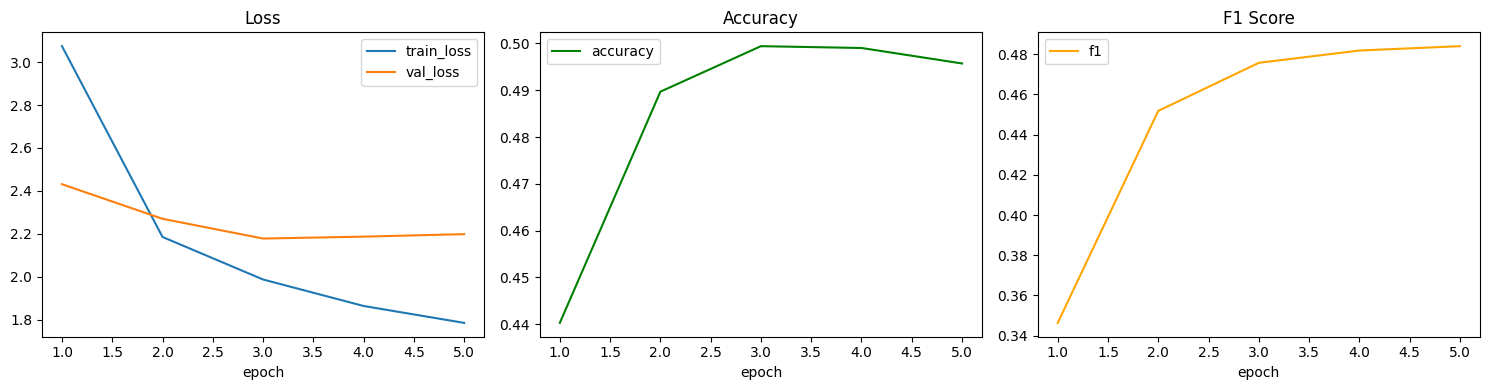

In [64]:
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

hist_df.plot(x='epoch', y=['train_loss', 'val_loss'], ax=axes[0], title='Loss')
hist_df.plot(x='epoch', y='accuracy', ax=axes[1], title='Accuracy', color='green')
hist_df.plot(x='epoch', y='f1', ax=axes[2], title='F1 Score', color='orange')

plt.tight_layout()
plt.savefig('/kaggle/working/model_output/training_plot.png')
plt.show()

# 05. Evaluation & Export
- Confusion matrix
- Per-class F1
- Test với câu tiếng Việt thật
- Export model weights + config

In [66]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import json, os
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder

In [67]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [68]:
# Load config và encoders
with open('/kaggle/working/model_output/config.json') as f:
    config = json.load(f)

with open('/kaggle/working/model_output/label_encoders.json') as f:
    encoders = json.load(f)

EMOTION_LABELS = encoders['emotions']
RISK_LABELS    = encoders['risks']
n_emotions     = len(EMOTION_LABELS)
n_risks        = len(RISK_LABELS)

print(f'Emotions: {EMOTION_LABELS}')
print(f'Risks: {RISK_LABELS}')

Emotions: ['anger', 'anticipation', 'disapproval', 'disgust', 'fear', 'joy', 'love', 'neutral', 'optimism', 'pessimism', 'remorse', 'sadness', 'surprise', 'trust']
Risks: ['crisis', 'high', 'low', 'moderate']


In [69]:
# Rebuild model
class MultiTaskEmotionModel(nn.Module):
    def __init__(self, model_name, n_emotions, n_risks, dropout=0.3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden = self.encoder.config.hidden_size
        self.emotion_head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, 256), nn.ReLU(), nn.Linear(256, n_emotions))
        self.risk_head    = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, 128), nn.ReLU(), nn.Linear(128, n_risks))
        self.valence_head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, 64),  nn.ReLU(), nn.Linear(64, 1), nn.Tanh())
        self.arousal_head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, 64),  nn.ReLU(), nn.Linear(64, 1), nn.Sigmoid())
        self.phq9_head    = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, 64),  nn.ReLU(), nn.Linear(64, 1), nn.Sigmoid())
    
    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        return {
            'emotion': self.emotion_head(cls),
            'risk':    self.risk_head(cls),
            'valence': self.valence_head(cls).squeeze(-1),
            'arousal': self.arousal_head(cls).squeeze(-1),
            'phq9':    self.phq9_head(cls).squeeze(-1) * 27,
        }

MODEL_NAME = config['model_name']
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
model = MultiTaskEmotionModel(MODEL_NAME, n_emotions, n_risks).to(device)
model.load_state_dict(torch.load('/kaggle/working/model_output/best_model.pt', map_location=device))
model.eval()
print('Model loaded')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded


In [70]:
# Predict
def predict(text, max_len=128):
    inputs = tokenizer(
        text, max_length=max_len,
        padding='max_length', truncation=True,
        return_tensors='pt'
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(inputs['input_ids'], inputs['attention_mask'])
    
    emotion_idx = outputs['emotion'].argmax(dim=-1).item()
    risk_idx    = outputs['risk'].argmax(dim=-1).item()
    
    emotion_probs = torch.softmax(outputs['emotion'], dim=-1)[0].cpu().numpy()
    
    return {
        'emotion':       EMOTION_LABELS[emotion_idx],
        'emotion_conf':  float(emotion_probs[emotion_idx]),
        'risk_level':    RISK_LABELS[risk_idx],
        'valence':       float(outputs['valence'].item()),
        'arousal':       float(outputs['arousal'].item()),
        'phq9_estimate': float(outputs['phq9'].item()),
    }

In [71]:
test_sentences = [
    'hôm nay rất vui, được gặp bạn bè sau bao lâu xa cách',
    'mệt mỏi quá, deadline dồn dập mà sếp cứ thêm việc',
    'lo lắng không biết kết quả thi như thế nào',
    'tức giận vì bị đối xử không công bằng',
    'cảm thấy trống rỗng, không biết mình đang sống để làm gì',
    'hạnh phúc vì gia đình bình an, cuộc sống ổn định',
    'không muốn làm gì cả, ngày nào cũng như ngày nào',
    'I am feeling really anxious about the future',
    'Today was a great day, everything went well',
]

print('\nPrediction results:')
print('='*70)
for text in test_sentences:
    result = predict(text)
    phq_level = 'Minimal' if result['phq9_estimate'] < 5 else \
                'Mild' if result['phq9_estimate'] < 10 else \
                'Moderate' if result['phq9_estimate'] < 15 else \
                'Severe'
    print(f'\nText: {text[:60]}...' if len(text) > 60 else f'\nText: {text}')
    print(f'  Emotion:  {result["emotion"]} (conf: {result["emotion_conf"]:.2f})')
    print(f'  Risk:     {result["risk_level"]}')
    print(f'  PHQ-9:    {result["phq9_estimate"]:.1f} → {phq_level}')
    print(f'  Valence:  {result["valence"]:.2f} | Arousal: {result["arousal"]:.2f}')


Prediction results:

Text: hôm nay rất vui, được gặp bạn bè sau bao lâu xa cách
  Emotion:  joy (conf: 0.86)
  Risk:     low
  PHQ-9:    2.9 → Minimal
  Valence:  0.75 | Arousal: 0.52

Text: mệt mỏi quá, deadline dồn dập mà sếp cứ thêm việc
  Emotion:  anger (conf: 0.29)
  Risk:     low
  PHQ-9:    2.8 → Minimal
  Valence:  -0.28 | Arousal: 0.53

Text: lo lắng không biết kết quả thi như thế nào
  Emotion:  anticipation (conf: 0.20)
  Risk:     low
  PHQ-9:    2.8 → Minimal
  Valence:  0.09 | Arousal: 0.64

Text: tức giận vì bị đối xử không công bằng
  Emotion:  anger (conf: 0.55)
  Risk:     low
  PHQ-9:    2.8 → Minimal
  Valence:  -0.50 | Arousal: 0.67

Text: cảm thấy trống rỗng, không biết mình đang sống để làm gì
  Emotion:  surprise (conf: 0.46)
  Risk:     low
  PHQ-9:    2.9 → Minimal
  Valence:  0.01 | Arousal: 0.52

Text: hạnh phúc vì gia đình bình an, cuộc sống ổn định
  Emotion:  joy (conf: 0.73)
  Risk:     low
  PHQ-9:    3.0 → Minimal
  Valence:  0.71 | Arousal: 0.49

Te

In [72]:
# Evaluation trên validation set
from torch.utils.data import Dataset, DataLoader

class EmotionDataset(Dataset):
    def __init__(self, df, tokenizer, le_emotion, le_risk, max_len=128):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.le_emotion = le_emotion
        self.le_risk = le_risk
        self.max_len = max_len
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        encoding = self.tokenizer(str(row['text'])[:512], max_length=self.max_len, padding='max_length', truncation=True, return_tensors='pt')
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'emotion_label':  torch.tensor(int(row['emotion_label']), dtype=torch.long),
        }

df = pd.read_csv('/kaggle/working/processed/emotion_dataset.csv')
le_emotion = LabelEncoder()
le_risk    = LabelEncoder()
df['emotion_label'] = le_emotion.fit_transform(df['primary_emotion'])
df['risk_label']    = le_risk.fit_transform(df['risk_level'])

from sklearn.model_selection import train_test_split
_, val_df = train_test_split(df, test_size=0.1, random_state=42, stratify=df['emotion_label'])

val_ds     = EmotionDataset(val_df, tokenizer, le_emotion, le_risk)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in val_loader:
        out = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
        preds  = out['emotion'].argmax(dim=-1).cpu().numpy()
        labels = batch['emotion_label'].numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)

print('Classification Report:')
print(classification_report(all_labels, all_preds, target_names=EMOTION_LABELS, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

       anger       0.38      0.51      0.44       593
anticipation       0.39      0.44      0.41       305
 disapproval       0.50      0.03      0.06       162
     disgust       0.00      0.00      0.00        99
        fear       1.00      0.02      0.04       111
         joy       0.59      0.46      0.52       745
        love       0.51      0.66      0.57       149
     neutral       0.51      0.68      0.59      1821
    optimism       0.59      0.36      0.44       112
   pessimism       0.00      0.00      0.00        19
     remorse       0.36      0.13      0.19        39
     sadness       0.39      0.31      0.35       235
    surprise       0.56      0.27      0.37       266
       trust       0.60      0.52      0.56       484

    accuracy                           0.50      5140
   macro avg       0.46      0.31      0.32      5140
weighted avg       0.51      0.50      0.48      5140



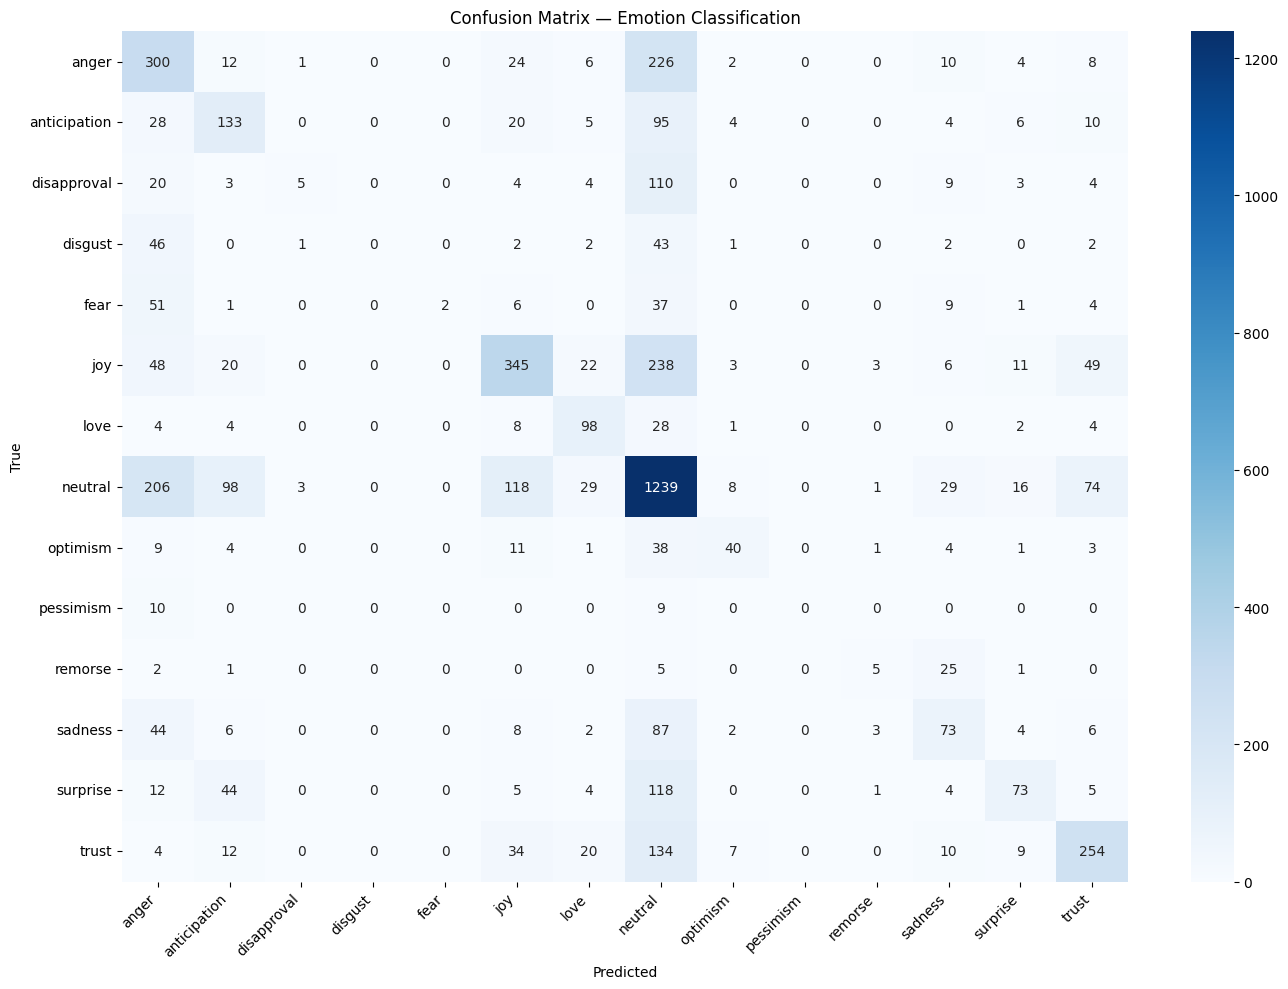

In [73]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS, cmap='Blues')
plt.title('Confusion Matrix — Emotion Classification')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/kaggle/working/model_output/confusion_matrix.png')
plt.show()

In [77]:
import os, json, shutil

os.makedirs('/kaggle/working/full_save', exist_ok=True)

# 1. GoEmotions đã dịch
shutil.copy('/kaggle/working/go_emotions_vi_full.csv', '/kaggle/working/full_save/')
shutil.copy('/kaggle/working/go_emotions_en_full.csv', '/kaggle/working/full_save/')

# 2. Processed datasets
shutil.copytree('/kaggle/working/processed', '/kaggle/working/full_save/processed')

# 3. Model output
shutil.copytree('/kaggle/working/model_output', '/kaggle/working/full_save/model_output')

# 4. Kaggle datasets đã download (tweet_eval, semeval, vsmec...)
shutil.copytree('/kaggle/working/data', '/kaggle/working/full_save/data')

# Metadata
with open('/kaggle/working/full_save/dataset-metadata.json', 'w') as f:
    json.dump({
        "title": "ripple-nlp-full",
        "id": "cass0618/ripple-nlp-full",
        "licenses": [{"name": "CC0-1.0"}]
    }, f)

print('Checking sizes...')
for item in os.listdir('/kaggle/working/full_save'):
    path = f'/kaggle/working/full_save/{item}'
    if os.path.isfile(path):
        size = os.path.getsize(path) / 1024 / 1024
        print(f'{item}: {size:.1f} MB')
    else:
        # folder size
        total = sum(os.path.getsize(os.path.join(dp,f)) 
                   for dp,dn,fns in os.walk(path) for f in fns)
        print(f'{item}/: {total/1024/1024:.1f} MB')

Checking sizes...
go_emotions_en_full.csv: 4.9 MB
go_emotions_vi_full.csv: 8.8 MB
dataset-metadata.json: 0.0 MB
data/: 1665.9 MB
processed/: 11.1 MB
model_output/: 516.9 MB


In [84]:
import json

with open('/kaggle/working/full_save/dataset-metadata.json', 'w') as f:
    json.dump({
        "title": "ripple-nlp-data-v2",
        "id": "cass0618/ripple-nlp-data-v2",
        "licenses": [{"name": "CC0-1.0"}]
    }, f)

!kaggle datasets create -p /kaggle/working/full_save --dir-mode zip

Starting upload for file go_emotions_en_full.csv
Error while trying to load upload info: KaggleObject.from_dict() got an unexpected keyword argument 'token'
100%|██████████████████████████████████████| 4.85M/4.85M [00:00<00:00, 10.4MB/s]
Upload successful: go_emotions_en_full.csv (5MB)
Starting upload for file go_emotions_vi_full.csv
Error while trying to load upload info: KaggleObject.from_dict() got an unexpected keyword argument 'token'
100%|██████████████████████████████████████| 8.76M/8.76M [00:00<00:00, 19.5MB/s]
Upload successful: go_emotions_vi_full.csv (9MB)
Starting upload for file data.zip
100%|█████████████████████████████████████████| 615M/615M [00:04<00:00, 141MB/s]
Upload successful: data.zip (615MB)
Starting upload for file processed.zip
100%|██████████████████████████████████████| 3.04M/3.04M [00:00<00:00, 7.94MB/s]
Upload successful: processed.zip (3MB)
Starting upload for file model_output.zip
100%|█████████████████████████████████████████| 480M/480M [00:04<00:00, 12